In [52]:
using GLPK, JuMP, Plots

model = Model(GLPK.Optimizer)

# alpha = 1.0; beta = 0.0   # only cost
alpha = 0.5; beta = 0.5   # balanced
# alpha = 0.2; beta = 0.8   # CO2-focused

T = 20      # Time
N = 20     # Anzahl Zeiteinheiten
M = 1
# 1 = Wärmepumpe        heat pump

# je Heizquelle
c = [25, 35, 80]         # COST              - €/MWh
s = [30, 40, 200]        # SUSTAINABILITY    - kg_CO2/MWh

# m = [350, 150, 100]     # max. MW
# je Zeitpunkt      
d = [10, 150, 200, 270, 0, 10, 200, 210, 70, 190, 180, 270, 20, 0, 100, 180, 140, 110, 160, 190]   # MW 
# Steigung - Steuerungsspontanität
k_heat = [100,30,100]        # max heat-up speed
k_cool = [100,30,100]        # max cool-down speed

#thermal storage
E_maxCharge = 60
E_maxDischarge = 60
# E_max = 200
E_start = 100
eff_charge = 0.9
eff_discharge = 0.9

@variable(model, E[1:N] >= 0)
@variable(model, charge[1:N] >= 0)
@variable(model, discharge[1:N] >= 0)
@variable(model, x[1:3,1:N] >= 0)
@variable(model, m>=0)
@variable(model, E_max>=0)
# KOSTEN minimieren
@objective( model, Min, alpha * sum( sum(x[j,t]*c[j] for t=1:N) for j=1:M) + 
                        beta * sum( sum(x[j,t]*s[j] for t=1:N) for j=1:M))
# CONSTRAINTS:
# kann maximalen Wirkungsgrad nicht übersteigen    -    je Heizquelle
@constraint(model, [j=1:M,t=1:N], x[j,t] <= m)
# DEMAND hast to be met     -    für alle Zeitpunkte i
# @constraint(model, [t=1:N],   sum( x[j,t] for j=1:M) >= d[t]    )

# heating speed
@constraint(model, [j=1:M, t=2:N],  x[j,t] - x[j,t-1] <= k_heat[j])
@constraint(model, [j=1:M, t=2:N],  x[j,t-1] - x[j,t] <= k_cool[j])

# SPEICHER
@constraint(model, [t=1:N], charge[t]    <= E_maxCharge)                                 # charging-speed
@constraint(model, [t=1:N], discharge[t] <= E_maxDischarge)
@constraint(model, [t=1:N], E[t]         <= E_max)                                       # storage-capazity
@constraint(model, [t=1:N], sum( x[i,t] for i=1:M) + discharge[t] >= d[t] + charge[t])      # heat-equality

@constraint(model, [t=2:N], E[t] == E[t-1] + eff_charge * charge[t] - 1/eff_discharge * discharge[t])          # keep track of storage
@constraint(model, E[1] == E_start + eff_charge * charge[1] - 1/eff_discharge * discharge[1])
@constraint(model, E[N] == E_start)
optimize!(model)

println("Solver status: ", termination_status(model))
println("Solution status: ", primal_status(model))
## Printing the solution
println("Objective value = ", objective_value(model)) 

cost = 0
# CO2 = 0

for j=1:M
    for i=1:N
        print(value(x[j,i]),"\t")
        cost += value(x[j,i])*c[j]
        CO2 += value(x[j,i])*s[j]
    end
    println(".")
end
println("\nHEATPUMP Capacity: ",value(m))
println("STORAGE Capacity: ",value(E_max))
println("Cost in €: ",round(cost,digits=2))
# println("CO2 in Kg: ", CO2)

Solver status: OPTIMAL
Solution status: FEASIBLE_POINT
Objective value = 76562.43093922653
15.524861878453038	115.52486187845304	200.0	210.00000000000003	110.0	66.51933701657457	166.51933701657458	210.0	110.0	190.0	180.0	210.00000000000006	110.00000000000006	10.00000000000006	100.0	180.0	140.0	110.0	160.0	190.0	.

HEATPUMP Capacity: 210.00000000000003
STORAGE Capacity: 104.97237569060772
Cost in €: 69602.21


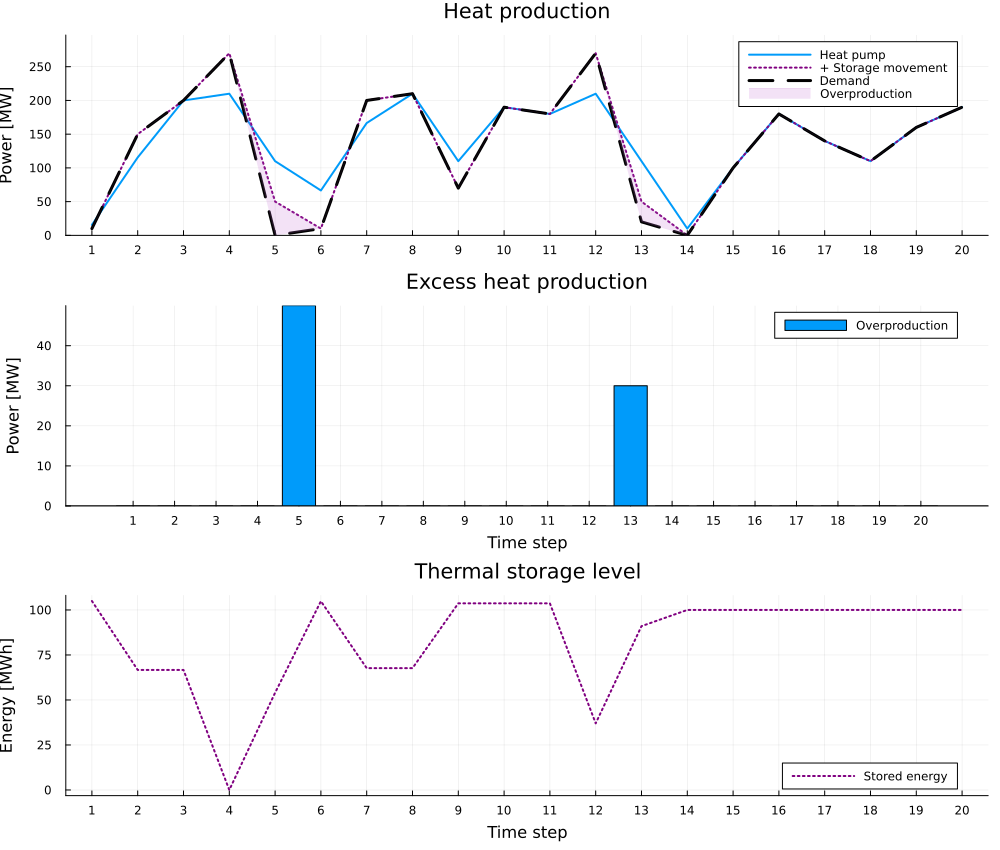

In [53]:
MovementStorage = value.(discharge) - value.(charge)
InStorage = value.(E)

x_result = value.(x)

hp  = x_result[1,:]
bio = hp .+ x_result[2,:]
gas = bio .+ x_result[3,:]
# tatsächlich für den Demand verfügbare Wärme
total = gas .+ MovementStorage

# Überproduktion
Overproduction = total .- d

ymax = maximum([maximum(total), maximum(d)]) * 1.1

# HEAT PRODUCTION
p1 = plot(1:N,hp,label="Heat pump",lw=2,title="Heat production",ylim=(0,ymax),xticks=1:N,grid=true)
plot!(p1, 1:N, total,label="+ Storage movement",lw=2,linestyle=:dot,color=:purple)
# Demand
plot!(p1, 1:N, d,label="Demand",lw=3,linestyle=:dash,color=:black)
# Bereich der Überproduktion markieren
plot!(p1, 1:N, total,fillrange=d,fillalpha=0.2,label="Overproduction",lw=0)
ylabel!(p1, "Power [MW]")

# OVERPRODUCTION
p2 = bar(1:N,Overproduction,label="Overproduction",title="Excess heat production",xlabel="Time step",ylabel="Power [MW]",xticks=1:N,grid=true)
hline!(p2, [0],color=:black,lw=1,label="")

# STORAGE LEVEL
p3 = plot(1:N,InStorage,label="Stored energy",title="Thermal storage level",xlabel="Time step",ylabel="Energy [MWh]",lw=2,linestyle=:dot,color=:purple,xticks=1:N,grid=true)

# ALL PLOTS
p = plot(p1,p2,p3,layout=(3,1),size=(1000,850))
display(p)

In [54]:
# MovementStorage = value.(discharge) - value.(charge)
# InStorage   = value.(E)

# p_power = plot(1:N,[value.(x[j,:]) for j in 1:M],labels="Heat pump",xlabel="Time step",ylabel="Power [MW]",lw=2,title="Heat generation", xticks=1:N, grid=true)
# plot!(p_power, 1:N, MovementStorage,label="StorageMovement",lw=2,linestyle=:dot,color=:purple)
# plot!(p_power, 1:N, d,label="Demand",lw=3,linestyle=:dash)

# p_storage = plot(1:N,InStorage,label="Stored energy",ylabel="Energy [MWh]",lw=2,title="Thermal storage level",linestyle=:dot,color=:purple, xticks=1:N,grid=true)   

# p = plot(p_power,p_storage,layout=(1,2),size=(1000,400))
# display(p)

# x_result = value.(x)

# hp  = x_result[1,:]
# total = hp .+ MovementStorage[:]
# # tes = gas .+ x_result[4,:]

# p1 = plot(1:N, hp, label="Heat pump", lw=2,title="MW in total")
# plot!(p1, 1:N, total, label="HP + Storage", lw=2, linestyle=:dot,color=:purple)
# plot!(p1, 1:N, d, label="Demand", lw=3, linestyle=:dash)

# # xlabel!(p1, "Time step")
# ylabel!(p1, "Power [MW]")
# display(p1)

In [55]:
# MovementStorage = value.(discharge) - value.(charge)
# InStorage   = value.(E)
# ymax = maximum(d)
# ymin = minimum([minimum(MovementStorage),0])

# p_power = plot(1:N,[value.(x[j,:]) for j in 1:3],labels=["Heat pump" "Biomass" "Gas"],xlabel="Time step",ylabel="Power [MW]",lw=2,title="Heat generation",ylim=(ymin,ymax), xticks=1:N, grid=true)
# plot!(p_power, 1:N, MovementStorage,label="StorageMovement",lw=2,linestyle=:dot,color=:purple)
# plot!(p_power, 1:N, d,label="Demand",lw=3,linestyle=:dash)

# p_storage = plot(1:N,InStorage,label="Stored energy",ylabel="Energy [MWh]",lw=2,title="Thermal storage level",linestyle=:dot,color=:purple, xticks=1:N,grid=true)   #,ylim=(ymin,ymax)

# annotate!(p_storage, 2, 300,
#     text("",
#          9, :left)
# )
# p = plot(p_power,p_storage,layout=(1,2),size=(1000,400))
# print("INTERPRET THE TWO GRAPHS, AS FOLLOWS:
# MovementStorage > 0 <=> storage discharges <=> Energy decreasing
# MovementStorage < 0 <=> storage charges  <=> Energy increasing"
# )
# display(p)

# x_result = value.(x)

# hp  = x_result[1,:]
# bio = hp .+ x_result[2,:]
# gas = bio .+ x_result[3,:]
# total = gas .+ MovementStorage[:]
# # tes = gas .+ x_result[4,:]

# p1 = plot(1:N, hp, label="Heat pump", lw=2,title="MW in total",ylim=(0,ymax))
# plot!(p1, 1:N, bio, label="+ Biomass", lw=2)
# plot!(p1, 1:N, gas, label="+ Gas", lw=2)
# plot!(p1, 1:N, total, label="+ MovementStorage", lw=2, linestyle=:dot,color=:purple)
# plot!(p1, 1:N, d, label="Demand", lw=3, linestyle=:dash)

# # xlabel!(p1, "Time step")
# ylabel!(p1, "Power [MW]")
# display(p1)